# EccoPy-1D — time series and transects

`eccopy1d` classifies a single ordered sequence of reflectivity, shaped
`(N,)`: a disdrometer or profiler time series, one radar ray, or a transect
through a gridded field.

```
reflectivity ──▶ texture ──▶ convectivity ──▶ echo type
               (sliding      (0–1 score)     (1 stratiform
                window along                  2 mixed
                the series)                   3 convective)
```

Two things set this module apart.

**The coordinate can be time or distance.** `coords` is whatever unit you
have — seconds, kilometres, or bare sample index — and the `WindowSpec`
unit has to match. This notebook uses a fixed-point time series, so the
texture window is sized in *minutes*, and measures how much reflectivity
varies as weather advects past the instrument. That is a different
quantity from the spatial texture the 2-D and 3-D modules compute, and it
tends to run higher.

**Output is basic only** — codes 1, 2 and 3. With no vertical axis there is
nothing to sub-classify.

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

from eccopy import eccopy1d, stats, time_to_distance_km
from eccopy.params import WindowSpec, TextureParams, ClassificationParams
from eccopy.core.colormaps import (
    basic_echo_type_cmap, basic_echo_type_norm, BASIC_ECHO_TYPE_LABELS,
    convectivity_cmap, convectivity_norm, remap_echo_type,
)

plt.rcParams["figure.dpi"] = 110

## 1. The data — and deriving reflectivity from it

24 hours of 1-minute drop-size distributions from a combined MRR/2DVD
disdrometer during TiMREX/SoWMEX (2008-06-27), spanning convective cells
embedded in lighter stratiform rain.

The file holds **no reflectivity field**. It stores the drop-size
distribution, and reflectivity is derived from it:

$$Z = \sum_i N(D_i)\, D_i^{6}\, \Delta D_i \qquad\qquad
\mathrm{dBZ} = 10 \log_{10} Z$$

This is deliberate. EccoPy takes plain arrays and never reads files, so
anything you can turn into a 1-D sequence of dBZ is valid input — it does
not have to have come from a radar.

In [2]:
ds = nc.Dataset("data/disdrometer_dsd_20080627.nc")

print(ds.title)
print(f"attribution : {ds.attribution}")
print()
for name, var in ds.variables.items():
    print(f"  {name:24s} {str(var.shape):14s} {var.units}")

MRR/2DVD drop-size distribution, 2008-06-27
attribution : TiMREX/SoWMEX; Ian Cornejo and Wei-Yu Chang

  time                     (1440,)        minutes since 1970-01-01 00:00:00.0
  particle_size            (110,)         mm
  particle_size_bin_width  (110,)         mm
  Nd                       (1440, 110)    mm^-1 m^-3


In [3]:
# netCDF4 hands back masked arrays; fill them so downstream numpy calls
# operate on plain ndarrays (nanmin/nanpercentile warn on masked input).
diameter = np.ma.filled(ds.variables["particle_size"][:].astype(float), np.nan)
bin_width = np.ma.filled(
    ds.variables["particle_size_bin_width"][:].astype(float), np.nan)
nd = np.ma.filled(ds.variables["Nd"][:].astype(float), np.nan)     # mm^-1 m^-3

# Z = sum over bins of N(D) * D^6 * dD, then dBZ.
z_linear = np.nansum(nd * diameter ** 6 * bin_width, axis=1)       # mm^6 m^-3
dbz = np.where(z_linear > 0,
               10.0 * np.log10(np.where(z_linear > 0, z_linear, 1.0)),
               np.nan)

# Time as seconds from the start of the record.
minutes = np.ma.filled(ds.variables["time"][:].astype(float), np.nan)
t_seconds = (minutes - minutes[0]) * 60.0
t_hours = t_seconds / 3600.0

print(f"{len(dbz)} samples at {np.median(np.diff(t_seconds)):.0f} s cadence "
      f"({t_hours[-1]:.1f} h)")
print(f"{np.isfinite(dbz).sum()} carry precipitation "
      f"({np.isfinite(dbz).mean():.0%} of the record)")
print(f"reflectivity {np.nanmin(dbz):.1f} to {np.nanmax(dbz):.1f} dBZ")

1440 samples at 60 s cadence (24.0 h)
816 carry precipitation (57% of the record)
reflectivity -14.9 to 53.3 dBZ


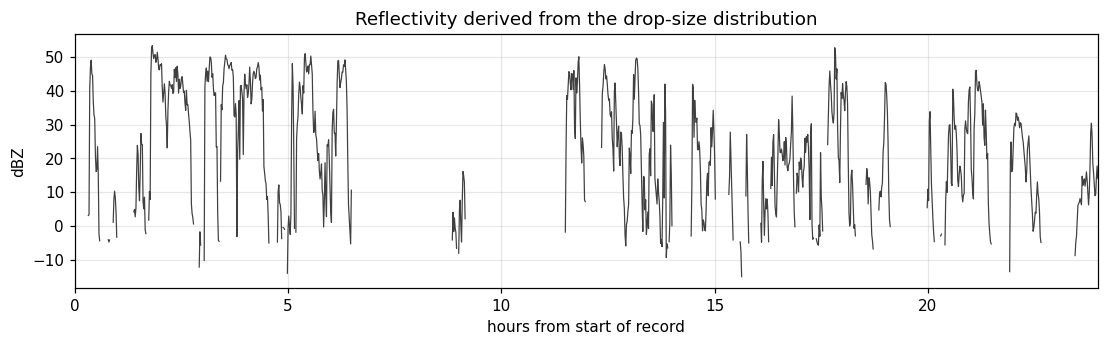

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_hours, dbz, lw=0.8, color="0.25")
ax.set_xlabel("hours from start of record"); ax.set_ylabel("dBZ")
ax.set_title("Reflectivity derived from the drop-size distribution")
ax.set_xlim(0, t_hours[-1]); ax.grid(alpha=0.3)
plt.show()

## 2. Sizing the window: time, or wind-advected distance

`WindowSpec` is unit-typed, and the unit has to agree with `coords`:

| `WindowSpec` | `coords` must be | meaning |
|---|---|---|
| `WindowSpec(15)` | anything | fixed 15-**sample** radius |
| `WindowSpec((15, "min"))` | seconds | 15-**minute** radius |
| `WindowSpec((5, "km"))` | kilometres | 5-**km** radius |

A fixed-point instrument gives you time. If you also have wind speed, you
can convert to a pseudo-spatial coordinate through Taylor's frozen-
turbulence hypothesis — distance = ∫|wind| dt — and then size the window
in kilometres, directly comparable to the 2-D and 3-D modules.

`time_to_distance_km()` does that conversion. It is a separate, composable
helper rather than something `run()` does for you: EccoPy does not assume
a wind field exists.

In [5]:
# With wind speed available, the same series can be given a distance
# coordinate instead. (No wind measurement ships with this sample, so this
# uses a nominal 12 m/s to show the mechanics.)
distance_km = time_to_distance_km(t_seconds, wind_speed_ms=12.0)

print(f"record spans {t_hours[-1]:.1f} h of time,")
print(f"        or {distance_km[-1]:.0f} km of advected distance at 12 m/s")
print(f"\na 15-minute window is equivalent to "
      f"{np.interp(15 * 60, t_seconds, distance_km):.1f} km at that speed")

# Either coordinate is valid input; they simply size the window differently.
# This notebook stays with time, so the window unit stays 'min'.

record spans 24.0 h of time,
        or 1036 km of advected distance at 12 m/s

a 15-minute window is equivalent to 10.8 km at that speed


## 3. Parameters

Sensitivity tiers were measured on *this* record; section 7 gives you the
tool to measure them on yours. `eccopy1d` uses a small subset of EccoPy's
parameters — anything about clumps, heights or temperatures has no meaning
for a single sequence.

### Texture

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `window` | larger → smoother texture | radius of the sliding window along the series | **moderate** |
| `texture_limit_high` | higher → lower convectivity | the normaliser: `convectivity = texture / texture_limit_high`, clipped to 1 | **high** |
| `dbz_base` | shifts the no-echo floor | subtracted before the variability statistic | **moderate** |
| `min_valid_dbz` | higher → weak echo dropped pre-texture | `None` resolves to *no gating* here, matching `f_reflTexture.m`, which has no such prefilter — unlike the 2-D-H and 3-D paths, where `None` means 0.0 | **high** |
| `kernel_mode` | window resolution strategy | identical on evenly-sampled series | **low** here |

### Classification

| Parameter | Direction | Mechanism | Sensitivity |
|---|---|---|---|
| `max_convectivity_for_stratiform` | higher → more stratiform | below this is stratiform; the gap to the next threshold is mixed | **moderate** |
| `min_convectivity_for_convective` | higher → less convective | at or above this is convective | **moderate** |
| `enlarge_conv` / `enlarge_mixed` | larger → runs grow and merge | morphological closing radius, applied along the series | **moderate** / **low** |
| `min_convective_length` | higher → brief bursts demoted | any contiguous convective run shorter than this becomes Mixed | **high** |

**`min_convective_length` is specific to this module.** It has no analogue
in the MATLAB or C++ reference — it is EccoPy's 1-D counterpart to the
volume filter `eccopy3d` applies to clumps, guarding against a momentary
spike surviving the morphological cleanup and being called convective. It
takes the same unit as `coords`, so a time series wants a time
`WindowSpec`.

In [6]:
window = WindowSpec((15, "min"))    # coords are in seconds, so 'min' applies

texture_params = TextureParams(
    dbz_base=0.0,             # reflectivity floor subtracted pre-texture
    texture_limit_high=30.0,  # convectivity normaliser
    min_valid_dbz=None,       # None -> no gating on the 1-D path
)

class_params = ClassificationParams(
    max_convectivity_for_stratiform=0.4,   # below this -> stratiform
    min_convectivity_for_convective=0.5,   # at/above this -> convective
    enlarge_mixed=5,                       # closing radius, mixed runs
    enlarge_conv=5,                        # closing radius, convective runs
)

print(f"window: {window}  (= {15 * 60} s radius on a "
      f"{np.median(np.diff(t_seconds)):.0f} s cadence, so "
      f"{int(15 * 60 / np.median(np.diff(t_seconds)))} samples either side)")

window: WindowSpec(15, 'min')  (= 900 s radius on a 60 s cadence, so 15 samples either side)


## 4. Running the classifier

`return_intermediates=True` adds `fitted_dbz` and `detrended_dbz`. On a 1-D
series it is cheap, unlike the 2-D-H path.

In [7]:
result = eccopy1d.run(
    dbz,
    coords=t_seconds,
    coord_mode="position",     # t_seconds is cumulative position, not spacing
    window=window,
    texture_params=texture_params,
    class_params=class_params,
    min_convective_length=None,   # see section 6
    kernel_mode="uniform",
    return_intermediates=True,
)

for name in ("texture", "convectivity", "echo_type", "fitted_dbz", "detrended_dbz"):
    arr = getattr(result, name)
    print(f"  {name:14s} {str(arr.shape):8s} {np.isfinite(arr).mean():6.1%} finite")

  texture        (1440,)   56.7% finite
  convectivity   (1440,)   56.7% finite
  echo_type      (1440,)   56.7% finite
  fitted_dbz     (1440,)  100.0% finite
  detrended_dbz  (1440,)   56.7% finite


## 5. The chain, stage by stage

The local linear fit is removed before variability is measured, so a slow
ramp in reflectivity — a stratiform band gradually intensifying — does not
register as texture. Only departures from that local trend do.

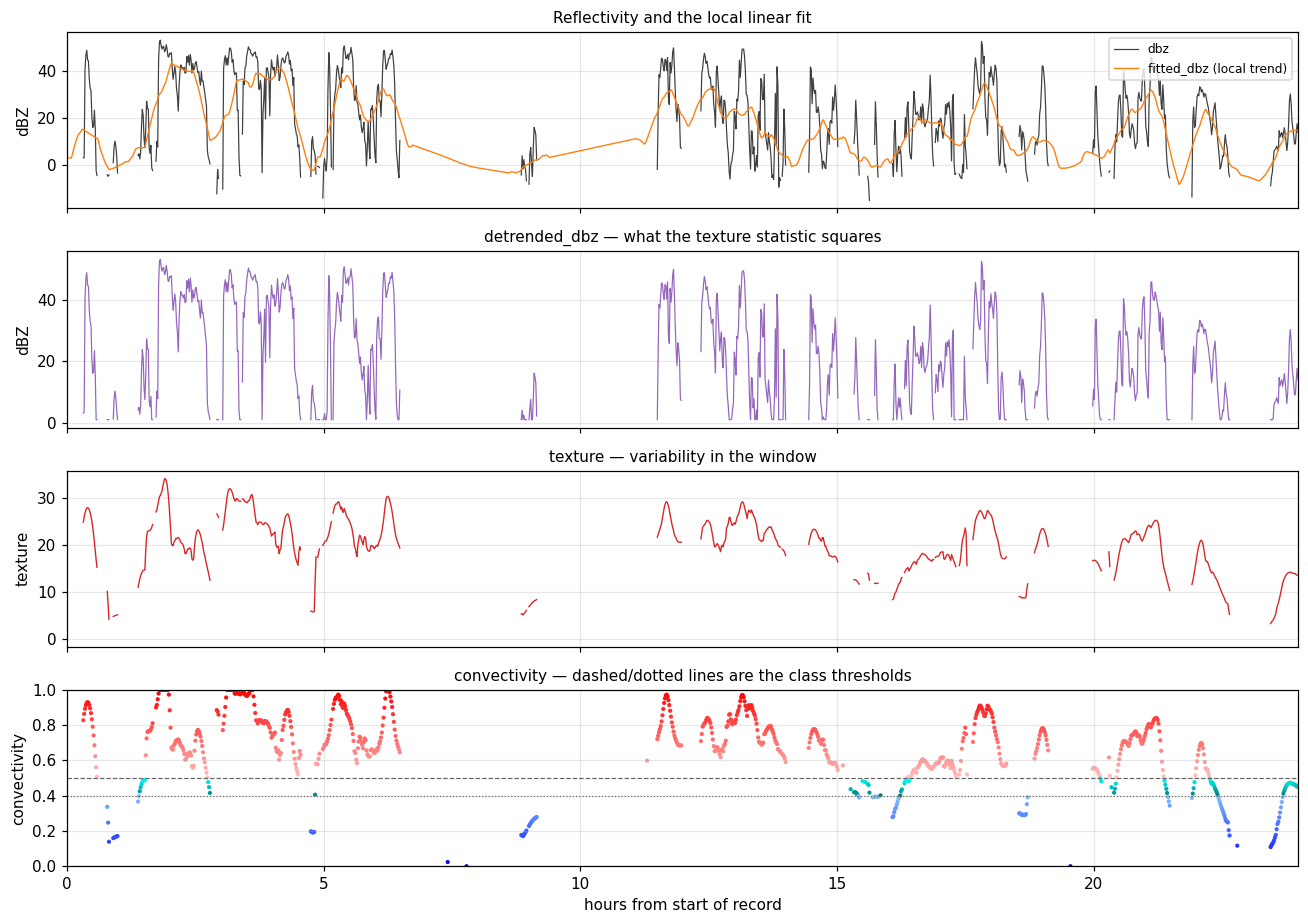

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8.5), sharex=True)

axes[0].plot(t_hours, dbz, lw=0.8, color="0.25", label="dbz")
axes[0].plot(t_hours, result.fitted_dbz, lw=0.9, color="tab:orange",
             label="fitted_dbz (local trend)")
axes[0].set_ylabel("dBZ"); axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_title("Reflectivity and the local linear fit", fontsize=10)

axes[1].plot(t_hours, result.detrended_dbz, lw=0.8, color="tab:purple")
axes[1].set_ylabel("dBZ")
axes[1].set_title("detrended_dbz — what the texture statistic squares", fontsize=10)

axes[2].plot(t_hours, result.texture, lw=0.9, color="tab:red")
axes[2].set_ylabel("texture")
axes[2].set_title("texture — variability in the window", fontsize=10)

sc = axes[3].scatter(t_hours, result.convectivity, c=result.convectivity, s=3,
                     cmap=convectivity_cmap(
                         strat_mixed=class_params.max_convectivity_for_stratiform,
                         mixed_conv=class_params.min_convectivity_for_convective),
                     norm=convectivity_norm())
for level, style in [(class_params.max_convectivity_for_stratiform, ":"),
                     (class_params.min_convectivity_for_convective, "--")]:
    axes[3].axhline(level, color="0.4", lw=0.8, ls=style)
axes[3].set_ylabel("convectivity"); axes[3].set_ylim(0, 1)
axes[3].set_title("convectivity — dashed/dotted lines are the class thresholds",
                  fontsize=10)

axes[-1].set_xlabel("hours from start of record")
for ax in axes:
    ax.grid(alpha=0.3); ax.set_xlim(0, t_hours[-1])
plt.tight_layout(); plt.show()

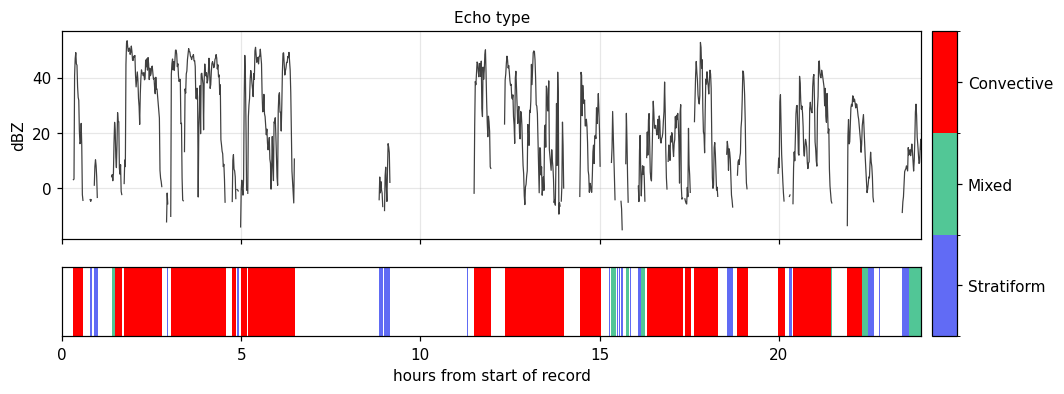

In [9]:
# The classification itself, as a colour strip beneath the series.
fig, axes = plt.subplots(2, 1, figsize=(12, 3.6), sharex=True,
                         height_ratios=[3, 1])

axes[0].plot(t_hours, dbz, lw=0.8, color="0.25")
axes[0].set_ylabel("dBZ"); axes[0].grid(alpha=0.3)

# imshow rather than pcolormesh: a single-row strip gives pcolormesh no
# way to infer cell height, so it draws an empty axis.
strip = remap_echo_type(result.echo_type)[None, :]
m = axes[1].imshow(strip, aspect="auto", origin="lower",
                   extent=[t_hours[0], t_hours[-1], 0, 1],
                   cmap=basic_echo_type_cmap(), norm=basic_echo_type_norm(),
                   interpolation="nearest")
axes[1].set_yticks([]); axes[1].set_xlabel("hours from start of record")
cb = fig.colorbar(m, ax=axes, ticks=range(1, 4), pad=0.01, aspect=12)
cb.ax.set_yticklabels(BASIC_ECHO_TYPE_LABELS)
axes[0].set_title("Echo type", fontsize=10)
axes[0].set_xlim(0, t_hours[-1])
plt.show()

## 6. `min_convective_length`

Morphological closing already removes single-sample noise, but a burst
lasting a few minutes can survive it and be labelled convective. If your
application needs a convective period to be sustained, this filter demotes
anything shorter to Mixed.

It takes a `WindowSpec` in the same unit as `coords` — here, minutes.

In [10]:
def convective_runs(echo):
    """Lengths, in samples, of each contiguous convective run."""
    conv = (echo == 3).astype(int)
    edges = np.diff(np.concatenate([[0], conv, [0]]))
    return np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)


cadence_min = np.median(np.diff(t_seconds)) / 60.0

for minutes_required in [None, 5, 15, 30]:
    mcl = None if minutes_required is None else WindowSpec((minutes_required, "min"))
    r = eccopy1d.run(dbz, coords=t_seconds, coord_mode="position", window=window,
                     texture_params=texture_params, class_params=class_params,
                     min_convective_length=mcl)
    runs = convective_runs(r.echo_type)
    label = "none" if minutes_required is None else f"{minutes_required} min"
    print(f"  min_convective_length {label:>8s}: "
          f"{len(runs):3d} convective runs, "
          f"shortest {runs.min() * cadence_min:5.1f} min, "
          f"convective {stats.convective_percentage(r.echo_type):5.1f}%")

  min_convective_length     none:  20 convective runs, shortest   5.0 min, convective  82.2%
  min_convective_length    5 min:  20 convective runs, shortest   5.0 min, convective  82.2%
  min_convective_length   15 min:  14 convective runs, shortest  17.0 min, convective  75.2%
  min_convective_length   30 min:   8 convective runs, shortest  35.0 min, convective  58.7%


## 7. Statistics

With no spatial or vertical axis, most of `eccopy.stats` does not apply —
`clump_sizes`, `echo_top_height` and the depth functions all need geometry
this module cannot provide. Coverage fractions still work, and
`n_clumps` degenerates usefully into "number of contiguous runs".

In [11]:
fractions = stats.echo_type_fractions(result.echo_type)
print(f"classified samples : {fractions['n_valid']}")
for name in ("stratiform", "mixed", "convective"):
    print(f"  {name:12s} {fractions[name]:6.1%}")

print(f"\ncontiguous convective runs : "
      f"{stats.n_clumps(result.echo_type, 'convective')}")

runs = convective_runs(result.echo_type)
if len(runs):
    print(f"  longest  {runs.max() * cadence_min:.0f} min")
    print(f"  median   {np.median(runs) * cadence_min:.0f} min")
    print(f"  total    {runs.sum() * cadence_min / 60:.1f} h of convective rain")

classified samples : 816
  stratiform    10.5%
  mixed          7.2%
  convective    82.2%

contiguous convective runs : 20
  longest  94 min
  median   25 min
  total    11.2 h of convective rain


A note on interpreting these numbers: this is a **point** measurement, so
"82 % convective" means 82 % of the *raining minutes* at one location were
convective, not 82 % of any area. Texture here is temporal variability, and
a fixed instrument sampling cells advecting past it sees more variability
than a spatial window would over the same weather. Do not compare 1-D
fractions against 2-D or 3-D ones directly.

## 8. Exploring parameters yourself

The tiers in section 3 came from this record. Measure them on yours.

In [12]:
from dataclasses import replace

BASE = dict(coords=t_seconds, coord_mode="position", window=window,
            texture_params=texture_params, class_params=class_params)


def sweep(values, make_kwargs, label=""):
    """Re-run across values and report disagreement against the baseline.

    make_kwargs(value) -> dict of run() overrides. Use dataclasses.replace()
    so only the swept field changes; rebuilding a params object by hand
    silently resets every field you omit.
    """
    reference = eccopy1d.run(dbz, **BASE).echo_type
    ref_mask = np.isin(reference, [1, 2, 3])

    print(label)
    for value in values:
        echo = eccopy1d.run(dbz, **{**BASE, **make_kwargs(value)}).echo_type
        mask = ref_mask | np.isin(echo, [1, 2, 3])
        changed = 100 * (1 - (reference[mask] == echo[mask]).mean())
        conv = stats.convective_percentage(echo)
        print(f"  {str(value):>8s}  {changed:5.1f}% changed"
              f"   convective {conv:5.1f}%")


sweep([5, 15, 30, 60], lambda v: dict(window=WindowSpec((v, "min"))),
      label="window radius (minutes)")

window radius (minutes)
         5    8.6% changed   convective  81.5%


        15    0.0% changed   convective  82.2%
        30    6.4% changed   convective  88.4%
        60    9.8% changed   convective  90.7%


In [13]:
sweep([20.0, 30.0, 40.0],
      lambda v: dict(texture_params=replace(texture_params, texture_limit_high=v)),
      label="texture_limit_high -- the convectivity normaliser")

sweep([None, 0.0, 15.0],
      lambda v: dict(texture_params=replace(texture_params, min_valid_dbz=v)),
      label="min_valid_dbz -- None means no gating on this path")

texture_limit_high -- the convectivity normaliser
      20.0   11.9% changed   convective  92.3%
      30.0    0.0% changed   convective  82.2%
      40.0   22.8% changed   convective  66.7%


min_valid_dbz -- None means no gating on this path
      None    0.0% changed   convective  82.2%
       0.0   16.5% changed   convective  82.1%
      15.0   46.7% changed   convective  84.3%


## Where to go next

- `eccopy2d_v` — vertical cross-sections, sub-typed from the melting layer
- `eccopy2d_h` — horizontal composites on a geographic grid
- `eccopy3d` — full volumes, sub-typed from clump geometry

Algorithm sources and the full parameter reference are in the top-level
`README.md`. Contributions are welcome — see `CONTRIBUTING.md`, especially
the ground-truth standard for changes to the classification path.